# 2a Escola de IA e Computação do CBPF (17-21/Ago/2026)

Curso de Astrofísica Computacional

Aula 2: Medidas de redshifts fotométricos de galáxias com aprendizado de máquina 

2.b) Medida de redshifts com florestas aleatórias

## Sumário

0. Introdução (descrição de ML, Decision Trees e Random Forest) (&#x2705; beta, v1)
1. Preparação de amostras de treino e teste (beta, v1)
2. ...

## Imports

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor

## Introdução

Os métodos de aprendizado de máquina que vamos empregar utilizam um subconjunto dos dados disponíveis para _treinar_ um algoritmo e outros subconjunto para _testar_ o resultado do treino e verificar a pe rformance do método em dados que não foram utilizados para o treinamento.

Esta linguagem é genérica e se aplica a todos os algoritmos, o que é prático para discutir os passos de uma dada análise. Por outro lado, ela obscurece o que está ocorrendo de fato no período de treinamento. Cada método possui seu próprio algoritmo, e estes possuem—na maior parte dos casos!—bases matemáticas robustas, calcadas na estatística e na teoria de otimização.

De forma muito resumida, **redes neurais** implementam numericamente um enorme "$f\odot g\odot h$" multidimensional, e o que chamamos de "treinamento" é o processo de tirar derivadas numéricas desta grande função multidimensional e não-linear buscando minimizar uma _função de perda_ (_loss function_), que no caso mais simples se trata de um $\chi^2$.

Já as **árvores de decisão** escolhem blablabalbalb.

**Florestas aleatórias** são um _ensemble method_ que treina múltiplas árvores de decisão, cada uma com blablablalal, e escolhe blablabla tal que blabalbala.

Neste notebook, vamos criar conjuntos de treino e teste (seção 1), aplicar cada um dos algoritmos acima aos nossos dados (seção 2) e avaliar sua performance (seção 3).

**FIXME:** Completar o texto desta célula.

## Exercício 1: Photo-zs com florestas aleatórias


### 1.a) Meça redshifts fotométricos usando as magnitudes disponíveis nos dados gerados na aula anterior

In [54]:
# Load the first CSV file (assumes it contains the test data)
data = pd.read_parquet("../../data/des_dr2/des_dr2_pz_training_set_clean_vvds_vipers_gama.pq")

# The 'z' columns is the target and the 'mag_*' and 'mag_err_' columns are the predictor
redshifts = data['z']
mags = data[['mag_auto_g_dered',
             'mag_auto_r_dered',
             'mag_auto_i_dered',
             'mag_auto_z_dered',
             'mag_auto_y_dered']]

In [56]:
# Split the data into training and test sets (e.g., 70/30 split)
Mags_train, Mags_test, z_spec_train, z_spec_test = train_test_split(mags, redshifts, test_size=0.3, random_state=42)

# Initialize the Random Forest Regressor with hyperparameters
rf = RandomForestRegressor(n_estimators=50,
                           max_depth=30,
                           max_features=None)

# Train and evaluate the Random Forest model
rf.fit(Mags_train, z_spec_train)
z_phot_mags = rf.predict(Mags_test)
print(f"Random Forest Validation MAE: {mean_absolute_error(z_spec_test, z_phot_mags)}")

Random Forest Validation MAE: 0.0568001379943615


### 1.b) Calculate metrics (cf slides) and plot zphot vs zspec for the train and test samples

In [57]:
def calculate_metrics(z_spec, z_phot):
    # Calculate the metrics
    metrics = {}
    metrics['mae'] = mean_absolute_error(z_spec, z_phot)
    metrics['rmse'] = np.sqrt(mean_squared_error(z_spec, z_phot))

    metrics['std'] = np.std((z_phot - z_spec)/(1 + z_spec), ddof=1)
    metrics['nmad'] = 1.4826 * np.median(np.abs((z_phot - z_spec)/(1 + z_spec)))
    metrics['eta'] = np.sum(np.abs((z_phot - z_spec)/(1 + z_spec)) > 0.15) / len(z_spec) # Catastrophic outlier fraction
    metrics['bias'] = np.mean((z_phot - z_spec)/(1 + z_spec))
    metrics['sigbias'] = metrics['std']/np.sqrt(0.64 * len(z_spec)) # Standard error of the bias

    print('Standard Deviation: %6.4f' % metrics['std'])
    print('Normalized MAD: %6.4f' % metrics['nmad'])
    print('Catastrophic Outlier Fraction: %6.4f' % (100 * metrics['eta']))
    print('Median offset: %6.3f +/- %6.3f' % (metrics['bias'], metrics['sigbias']))

    return metrics


def plot_predictions(y_true, y_pred, title):
    x = np.linspace(min(y_true), max(y_true), 100)
    outlier_upper = x + 0.15 * (1 + x)
    outlier_lower = x - 0.15 * (1 + x)

    mask = np.abs((y_pred - y_true)/(1 + y_true)) > 0.15

    plt.figure(figsize=(4, 3))
    plt.scatter(y_true[mask], y_pred[mask], alpha=0.5, s=5, color='red', label='Outliers')
    plt.scatter(y_true[~mask], y_pred[~mask], alpha=0.5, s=5, color='blue', label='Non-Outliers')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r')  # Diagonal line
    plt.plot(x, outlier_upper, 'k--')
    plt.plot(x, outlier_lower, 'k--')
    plt.xlabel('True Redshift')
    plt.ylabel('Predicted Redshift')
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.xlim(0, 2)
    plt.ylim(0, 2)
    plt.show()

In [58]:
from matplotlib.colors import LogNorm


def plot_predictions_density(y_true, y_pred, title, *,
                             gridsize=40, cmap='Blues', outlier_thresh=0.15,
                             zlim=(0, 2), vmax=None, ax=None):
    """Same panel as plot_predictions, but the bulk of the galaxies is drawn as a
    density map instead of individual points.

    With samples this large the non-outlier cloud saturates into a solid blob and
    hides exactly what we want to see: how tight the core of the z_phot-z_spec
    relation is. Here that cloud becomes a log-scaled hexagonal binning, while the
    catastrophic outliers stay as scatter points on top so they remain countable.

    Args:
        y_true, y_pred: spectroscopic and photometric redshifts (same length).
        title: panel title.

    Kwargs:
        gridsize: number of hexagons across the x axis.
        cmap: sequential (light -> dark) colormap for the density.
        outlier_thresh: |dz/(1+z)| above which a galaxy is a catastrophic outlier.
        zlim: (min, max) redshift range, used for both axes and the hex grid.
        vmax: upper end of the color scale. Fix it to the same value across
            several panels to compare them honestly; None autoscales each panel.
        ax: draw into an existing Axes instead of making a new figure.

    Returns:
        (fig, ax)
    """
    # np.asarray: the call sites pass pandas Series, and boolean masking a Series
    # follows its index rather than its position.
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.abs((y_pred - y_true)/(1 + y_true)) > outlier_thresh

    own_figure = ax is None
    if own_figure:
        fig, ax = plt.subplots(figsize=(5, 4.2))
    else:
        fig = ax.figure

    # Density of the well-behaved galaxies. mincnt=1 leaves genuinely empty cells
    # white (so "no galaxy" and "one galaxy" stay distinguishable), and LogNorm
    # keeps the dense diagonal core from flattening everything else to one shade.
    hexes = None
    if (~mask).any():
        hexes = ax.hexbin(y_true[~mask], y_pred[~mask],
                          gridsize=gridsize, cmap=cmap, linewidths=0, mincnt=1,
                          norm=LogNorm(vmin=1, vmax=vmax),
                          extent=(zlim[0], zlim[1], zlim[0], zlim[1]))

    # The outliers are sparse by construction, so they stay discrete points. The
    # thin white edge keeps them readable where they pile up on each other.
    if mask.any():
        ax.scatter(y_true[mask], y_pred[mask], s=8, c='#d62728',
                   edgecolor='white', linewidth=0.4, zorder=3,
                   label='Outliers (%d)' % mask.sum())
        ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

    # Identity line in neutral gray: red now belongs to the outliers alone.
    x = np.linspace(zlim[0], zlim[1], 200)
    ax.plot(x, x, color='0.25', linewidth=1.2, zorder=2)
    ax.plot(x, x + outlier_thresh * (1 + x), linestyle='--', color='0.45', linewidth=1, zorder=2)
    ax.plot(x, x - outlier_thresh * (1 + x), linestyle='--', color='0.45', linewidth=1, zorder=2)

    if hexes is not None and own_figure:
        fig.colorbar(hexes, ax=ax, label='Galaxies per cell')

    ax.set_xlabel('True Redshift')
    ax.set_ylabel('Predicted Redshift')
    ax.set_title(title)
    ax.set_xlim(zlim)
    ax.set_ylim(zlim)
    ax.set_aspect('equal')  # both axes are redshift, so the diagonal must read at 45 deg
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)  # otherwise the grid is drawn on top of the hexagons

    if own_figure:
        plt.show()

    return fig, ax


Standard Deviation: 0.0581
Normalized MAD: 0.0381
Catastrophic Outlier Fraction: 2.3408
Median offset:  0.002 +/-  0.000


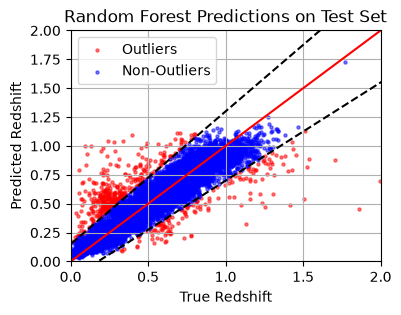

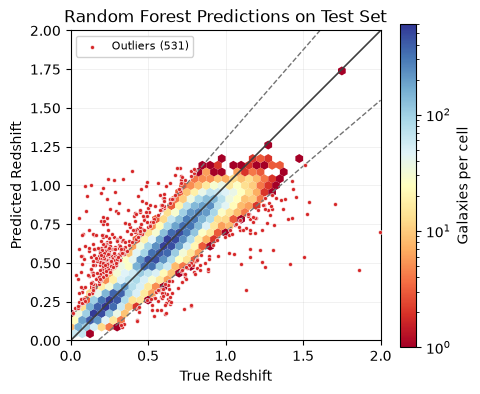

In [59]:
# Results on test set
_ = calculate_metrics(z_spec_test, z_phot_mags)
_ = plot_predictions(z_spec_test, z_phot_mags, "Random Forest Predictions on Test Set")
_ = plot_predictions_density(z_spec_test, z_phot_mags, "Random Forest Predictions on Test Set", cmap='RdYlBu')

#### A side note: a practical example of overfitting

In [60]:
y_train_pred_rf, y_train = train_and_evaluate_rf(X_train, y_train, X_train, y_train)

Random Forest Validation MAE: 0.02141319716587926


Standard Deviation: 0.0582
Normalized MAD: 0.0381
Catastrophic Outlier Fraction: 2.3143
Median offset:  0.003 +/-  0.000


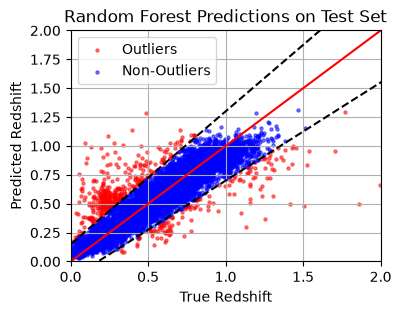

Standard Deviation: 0.0220
Normalized MAD: 0.0140
Catastrophic Outlier Fraction: 0.1455
Median offset:  0.001 +/-  0.000


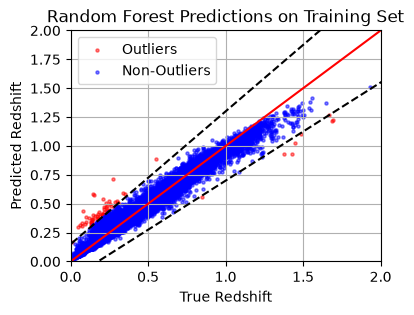

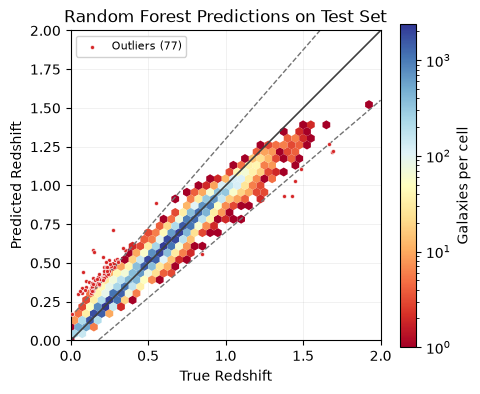

In [61]:
# Results on test set
_ = calculate_metrics(y_test, y_pred_rf)
_ = plot_predictions(y_test, y_pred_rf, "Random Forest Predictions on Test Set")

# Results on training set - WRONG, TOO OPTIMISTIC!
_ = calculate_metrics(y_train, y_train_pred_rf)
_ = plot_predictions(y_train, y_train_pred_rf, "Random Forest Predictions on Training Set")
_ = plot_predictions_density(y_train, y_train_pred_rf, "Random Forest Predictions on Test Set", cmap='RdYlBu')

### 1.c) Use k-fold cross-validation

In [62]:
n_folds = 5
del rf
rf = RandomForestRegressor(n_estimators=50,
                           max_depth=30,
                           max_features=None) # FIXME: Which hyperparameters should we use? (n_estimators, max_depth, etc.)


y_pred_cross_val = cross_val_predict(rf, mags, redshifts, cv=n_folds)

Standard Deviation: 0.0582
Normalized MAD: 0.0381
Catastrophic Outlier Fraction: 2.3143
Median offset:  0.003 +/-  0.000


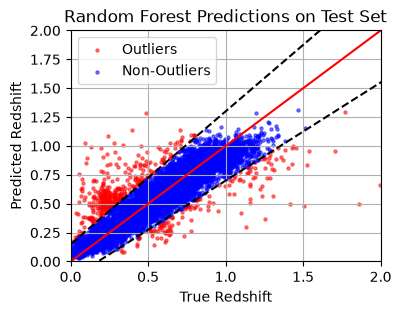

Standard Deviation: 0.0614
Normalized MAD: 0.0388
Catastrophic Outlier Fraction: 2.7983
Median offset:  0.004 +/-  0.000


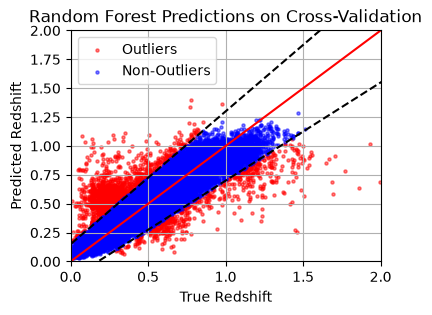

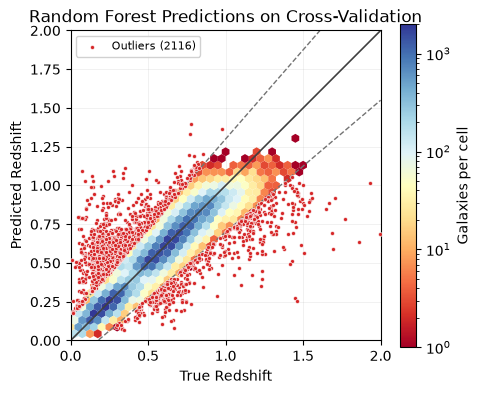

In [64]:
# Results on test set
_ = calculate_metrics(y_test, y_pred_rf)
_ = plot_predictions(y_test, y_pred_rf, "Random Forest Predictions on Test Set")

# Results on cross-validation - more realistic!
_ = calculate_metrics(redshifts, y_pred_cross_val)
_ = plot_predictions(redshifts, y_pred_cross_val, "Random Forest Predictions on Cross-Validation")
_ = plot_predictions_density(redshifts, y_pred_cross_val, "Random Forest Predictions on Cross-Validation", cmap='RdYlBu')

### 2.a) Crie subconjuntos dos dados com as colunas necessárias para cada um dos testes planejados

In [65]:
print(data.columns.values)

<ArrowStringArray>
[ 'coadd_object_id',               'ra',              'dec',
                'z',            'err_z',         'flag_des',
           'survey',      'flag_survey', 'mag_auto_g_dered',
 'mag_auto_r_dered', 'mag_auto_i_dered', 'mag_auto_z_dered',
 'mag_auto_y_dered',    'magerr_auto_g',    'magerr_auto_r',
    'magerr_auto_i',    'magerr_auto_z',    'magerr_auto_y',
           'ra_mpl',          'dec_mpl',        'g_minus_r',
        'r_minus_i',        'i_minus_z',        'z_minus_y']
Length: 24, dtype: str


In [66]:
# Load the first CSV file (assumes it contains the test data)
data = pd.read_parquet("../../data/des_dr2/des_dr2_pz_training_set_clean_vvds_vipers_gama.pq")

# The 'z' columns is the target and the 'mag_*' and 'mag_err_' columns are the predictor
redshifts = data['z']
mags = data[['mag_auto_g_dered',
             'mag_auto_r_dered',
             'mag_auto_i_dered',
             'mag_auto_z_dered',
             'mag_auto_y_dered']]

colors = data[['g_minus_r',
               'r_minus_i',
               'i_minus_z',
               'z_minus_y']]

clrmag = data[['g_minus_r',
               'r_minus_i',
               'i_minus_z',
               'z_minus_y',
               'mag_auto_i_dered']]

mags_werr = data[['mag_auto_g_dered',
                  'mag_auto_r_dered',
                  'mag_auto_i_dered',
                  'mag_auto_z_dered',
                  'mag_auto_y_dered',
                  'magerr_auto_g',
                  'magerr_auto_r',
                  'magerr_auto_i',
                  'magerr_auto_z',
                  'magerr_auto_y']]

clrmag_werr = data[['g_minus_r',
                    'r_minus_i',
                    'i_minus_z',
                    'z_minus_y',
                    'mag_auto_i_dered',
                    'magerr_auto_g',
                    'magerr_auto_r',
                    'magerr_auto_i',
                    'magerr_auto_z',
                    'magerr_auto_y']]

#### Colors

In [67]:
# Split the data into training and test sets (e.g., 70/30 split)
del rf
rf = RandomForestRegressor(n_estimators=50,
                           max_depth=30,
                           max_features=None) # FIXME: Which hyperparameters should we use? (n_estimators, max_depth, etc.)

X_train_color, X_test_color, y_train_color, y_test_color = train_test_split(colors, redshifts, test_size=0.3, random_state=42)
y_pred_colors, y_test_colors = train_and_evaluate_rf(X_train_color, y_train_color, X_test_color, y_test_color)

Random Forest Validation MAE: 0.06591876001662528


#### Colors + Magnitudes

In [68]:
from sklearn.base import clone
rf = clone(rf)   

X_train_clrmag, X_test_clrmag, y_train_clrmag, y_test_clrmag = train_test_split(clrmag, redshifts, test_size=0.3, random_state=42)
y_pred_clrmag, y_test_clrmag = train_and_evaluate_rf(X_train_clrmag, y_train_clrmag, X_test_clrmag, y_test_clrmag)

Random Forest Validation MAE: 0.053116927604084534


In [69]:
rf = clone(rf)   
X_train_mag_werr, X_test_mag_werr, y_train_mag_werr, y_test_mag_werr = train_test_split(mags_werr, redshifts, test_size=0.3, random_state=42)
y_pred_mag_werr, y_test_mag_werr = train_and_evaluate_rf(X_train_mag_werr, y_train_mag_werr, X_test_mag_werr, y_test_mag_werr)

Random Forest Validation MAE: 0.06164261975541091


In [70]:
rf = clone(rf)   
X_train_clrmag_werr, X_test_clrmag_werr, y_train_clrmag_werr, y_test_clrmag_werr = train_test_split(clrmag_werr, redshifts, test_size=0.3, random_state=42)
y_pred_clrmag_werr, y_test_clrmag_werr = train_and_evaluate_rf(X_train_clrmag_werr, y_train_clrmag_werr, X_test_clrmag_werr, y_test_clrmag_werr)

Random Forest Validation MAE: 0.05174986612864657


#### Plots

Standard Deviation: 0.0582
Normalized MAD: 0.0381
Catastrophic Outlier Fraction: 2.3143
Median offset:  0.003 +/-  0.000


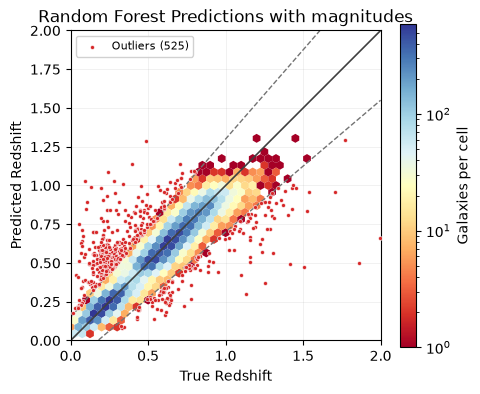

Standard Deviation: 0.0696
Normalized MAD: 0.0405
Catastrophic Outlier Fraction: 4.6859
Median offset:  0.004 +/-  0.001


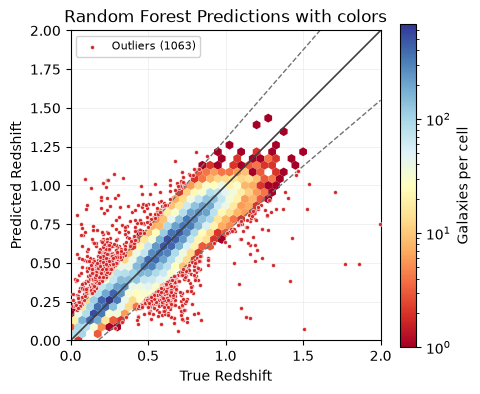

Standard Deviation: 0.0566
Normalized MAD: 0.0340
Catastrophic Outlier Fraction: 2.0895
Median offset:  0.003 +/-  0.000


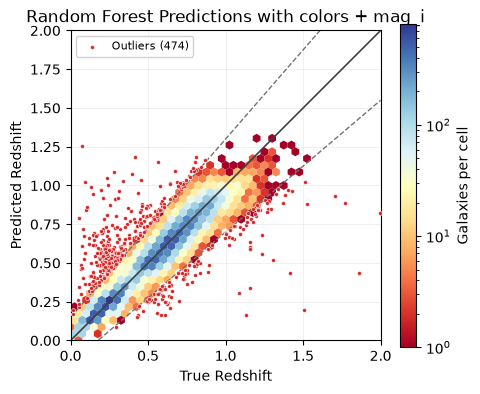

Standard Deviation: 0.0618
Normalized MAD: 0.0429
Catastrophic Outlier Fraction: 2.5171
Median offset:  0.003 +/-  0.001


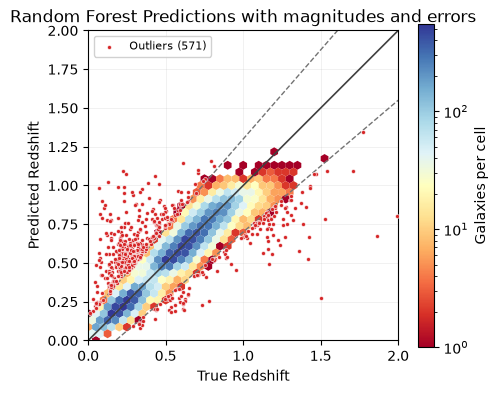

Standard Deviation: 0.0546
Normalized MAD: 0.0330
Catastrophic Outlier Fraction: 1.9352
Median offset:  0.003 +/-  0.000


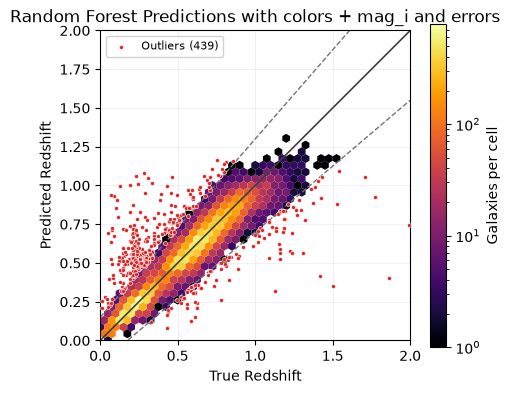

In [71]:
# Results on test set
_ = calculate_metrics(y_test, y_pred_rf)
_ = plot_predictions_density(y_test, y_pred_rf, "Random Forest Predictions with magnitudes", cmap='RdYlBu')

# Results on colors test set
_ = calculate_metrics(y_test_colors, y_pred_colors)
_ = plot_predictions_density(y_test_colors, y_pred_colors, "Random Forest Predictions with colors", cmap='RdYlBu')

# Results on colors + mag_i test set
_ = calculate_metrics(y_test_clrmag, y_pred_clrmag)
_ = plot_predictions_density(y_test_clrmag, y_pred_clrmag, "Random Forest Predictions with colors + mag_i", cmap='RdYlBu')

# Results on magnitudes with errors test set
_ = calculate_metrics(y_test_mag_werr, y_pred_mag_werr)
_ = plot_predictions_density(y_test_mag_werr, y_pred_mag_werr, "Random Forest Predictions with magnitudes and errors", cmap='RdYlBu')


# Results on colors + mag_i with errors test set
_ = calculate_metrics(y_test_clrmag_werr, y_pred_clrmag_werr)
_ = plot_predictions_density(y_test_clrmag_werr, y_pred_clrmag_werr, "Random Forest Predictions with colors + mag_i and errors", cmap='inferno')

#### Todos os conjuntos de atributos num único laço

Em vez de treinar cada conjunto de atributos numa célula separada, o laço abaixo
treina os cinco de uma vez e guarda tudo num dicionário `results`. Cada painel é
desenhado num objeto `Axes`, o que permite combiná-los numa única figura com uma
escala de cor comum.


In [72]:
def plot_predictions_panel(y_true, y_pred, title, ax=None, *,
                           metrics=None, show_metrics=True,
                           gridsize=40, cmap='inferno', outlier_thresh=0.15,
                           zlim=(0, 2), vmax=None):
    """Axes-first version of plot_predictions_density, meant to fill one slot of a
    grid of panels.

    Differences from plot_predictions_density:
      - ax is a positional argument, since driving a subplot grid is the main use;
      - it draws no colorbar and never calls plt.show(), because a panel must not
        take over the figure it lives in;
      - it returns the hexbin mappable so the caller can build a single shared
        colorbar and force one common colour scale across all panels;
      - the outlier count is reported as a percentage of the sample;
      - a box with the quality metrics is written into the panel.

    Args:
        y_true, y_pred: spectroscopic and photometric redshifts (same length).
        title: panel title.
        ax: Axes to draw into. None makes a standalone figure.

    Kwargs:
        metrics: dict returned by calculate_metrics. Pass it to reuse values that
            are already computed; if None, the three numbers shown are computed
            here (silently - calculate_metrics prints, which we do not want in the
            middle of a plotting routine). Note that calculate_metrics hardcodes a
            0.15 threshold for eta, so a dict passed in together with a different
            outlier_thresh will disagree with the legend on purpose.
        show_metrics: set False to drop the metrics box.
        gridsize: number of hexagons across the x axis.
        cmap: sequential (light -> dark) colormap for the density.
        outlier_thresh: |dz/(1+z)| above which a galaxy is a catastrophic outlier.
        zlim: (min, max) redshift range, used for both axes and the hex grid.
        vmax: upper end of the colour scale; None autoscales this panel.

    Returns:
        (ax, hexes), where hexes is the hexbin mappable, or None if every galaxy
        in the sample is an outlier.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    dz = (y_pred - y_true)/(1 + y_true)
    mask = np.abs(dz) > outlier_thresh

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.6))

    hexes = None
    if (~mask).any():
        hexes = ax.hexbin(y_true[~mask], y_pred[~mask],
                          gridsize=gridsize, cmap=cmap, linewidths=0, mincnt=1,
                          norm=LogNorm(vmin=1, vmax=vmax),
                          extent=(zlim[0], zlim[1], zlim[0], zlim[1]))

    if mask.any():
        ax.scatter(y_true[mask], y_pred[mask], s=8, c='#d62728',
                   edgecolor='white', linewidth=0.4, zorder=3,
                   label='Outliers: %.2f%%' % (100 * mask.mean()))
        ax.legend(loc='upper left', fontsize=8, framealpha=0.9, handletextpad=0.2)

    x = np.linspace(zlim[0], zlim[1], 200)
    ax.plot(x, x, color='0.25', linewidth=1.2, zorder=2)
    ax.plot(x, x + outlier_thresh * (1 + x), linestyle='--', color='0.45', linewidth=1, zorder=2)
    ax.plot(x, x - outlier_thresh * (1 + x), linestyle='--', color='0.45', linewidth=1, zorder=2)

    if show_metrics:
        if metrics is None:
            metrics = {'nmad': 1.4826 * np.median(np.abs(dz)),
                       'eta':  mask.mean(),
                       'bias': np.mean(dz)}
        # Lower right is the empty corner: the legend sits upper left and the
        # galaxies pile up along the diagonal. Monospace so the values line up.
        ax.text(0.97, 0.04,
                'σ_NMAD = %6.4f\nη      = %5.2f %%\nbias   = %+7.4f'
                % (metrics['nmad'], 100 * metrics['eta'], metrics['bias']),
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, family='monospace', zorder=4,
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                          alpha=0.85, edgecolor='0.7'))

    ax.set_xlabel('True Redshift')
    ax.set_ylabel('Predicted Redshift')
    ax.set_title(title)
    ax.set_xlim(zlim)
    ax.set_ylim(zlim)
    ax.set_aspect('equal')
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

    return ax, hexes


In [73]:
from sklearn.base import clone

feature_sets = {
    'Magnitudes':              mags,
    'Colors':                  colors,
    'Colors + mag_i':          clrmag,
    'Magnitudes + errors':     mags_werr,
    'Colors + mag_i + errors': clrmag_werr,
}

rf_base = RandomForestRegressor(n_estimators=50,
                                max_depth=30,
                                max_features=None)

results = {}
for name, X in feature_sets.items():
    # Same random_state and same target for every feature set, so the splits are
    # identical row-by-row: the panels then differ only by the features used,
    # never by which galaxies happened to land in the test set.
    X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
        X, redshifts, test_size=0.3, random_state=42)

    model = clone(rf_base)          # fresh, unfitted, same hyperparameters
    model.fit(X_train_fs, y_train_fs)
    y_pred_fs = model.predict(X_test_fs)

    print('\n--- %s (%d features) ---' % (name, X.shape[1]))
    results[name] = {'y_true':  y_test_fs,
                     'y_pred':  y_pred_fs,
                     'model':   model,     # kept so feature importances can be
                                           # inspected later without retraining
                     'metrics': calculate_metrics(y_test_fs, y_pred_fs)}



--- Magnitudes (5 features) ---
Standard Deviation: 0.0580
Normalized MAD: 0.0384
Catastrophic Outlier Fraction: 2.3231
Median offset:  0.002 +/-  0.000

--- Colors (4 features) ---
Standard Deviation: 0.0700
Normalized MAD: 0.0402
Catastrophic Outlier Fraction: 4.7432
Median offset:  0.004 +/-  0.001

--- Colors + mag_i (5 features) ---
Standard Deviation: 0.0564
Normalized MAD: 0.0339
Catastrophic Outlier Fraction: 2.0145
Median offset:  0.003 +/-  0.000

--- Magnitudes + errors (10 features) ---
Standard Deviation: 0.0615
Normalized MAD: 0.0427
Catastrophic Outlier Fraction: 2.4862
Median offset:  0.003 +/-  0.001

--- Colors + mag_i + errors (10 features) ---
Standard Deviation: 0.0547
Normalized MAD: 0.0330
Catastrophic Outlier Fraction: 1.9969
Median offset:  0.003 +/-  0.000


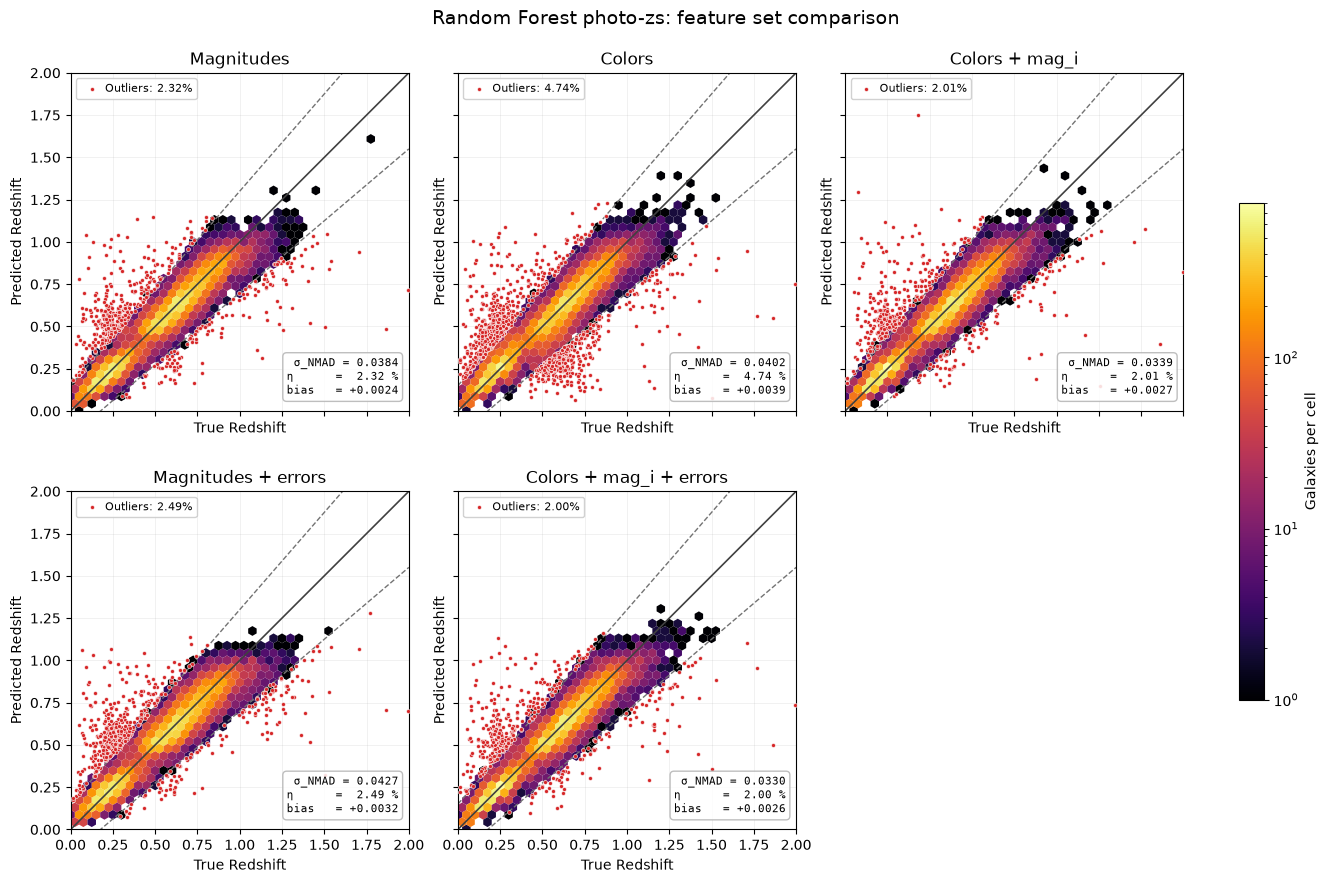

In [74]:
ncols = 3
nrows = int(np.ceil(len(results) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.4 * nrows),
                         sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)

mappables = []
for ax, (name, result) in zip(axes.flat, results.items()):
    _, hexes = plot_predictions_panel(result['y_true'], result['y_pred'], name, ax,
                                      metrics=result['metrics'])
    mappables.append(hexes)

# Blank the leftover slot (5 feature sets in a 2x3 grid).
for ax in list(axes.flat)[len(results):]:
    ax.set_visible(False)

# One colour scale shared by every panel. Without this each hexbin autoscales on
# its own counts and the darkest blue means something different in each panel.
vmax = max(h.get_array().max() for h in mappables if h is not None)
for h in mappables:
    if h is not None:
        h.set_clim(1, vmax)

fig.colorbar(mappables[0], ax=axes.ravel().tolist(),
             label='Galaxies per cell', shrink=0.6)
_ = fig.suptitle('Random Forest photo-zs: feature set comparison', fontsize=14)


## Exercício 2:  Métricas de qualidade e otimização de hiperparâmetros

## Exercício 3: Testando variantes na escolha das análises

In [79]:
def plot_metrics(zspec,
                 zphot,
                 maximum,
                 path_to_save='',
                 title=None,
                 initial=0):
    
    '''
    Function to plot Bias, Sigma_68, Out2σ, Out3σ given a spectroscopic and photometric redshift. 
    
    Args:
    
    zspec: Numpy array with the spectroscopic redshift.
    
    zphot: Numpy array with the photometric redshifts calculated. Same size as zspec.
    
    maximum: Float that indicates the redshift max of the plots.
    
    Kwargs:
    
    initial: Float that indicates the redshift min of the plots.
    
    
    
    '''
    bins = np.arange(0, 1.3, 0.1)
    points = bins + 0.05
    fraction_outliers = []
    sigma68z = []
    sigmaz = []
    meanz = []
    outliers_2 = []
    drop_bins = []

    for index in range(len(bins) - 1):
        bin_lower = bins[index]
        bin_upper = bins[index + 1]

        binmask = (zphot >= bin_lower) & (zphot <= bin_upper)

        if not np.any(binmask):
            drop_bins.append(index)
            continue
        
        values_r = zphot[binmask]
        values_s = zspec[binmask]

        deltabias = (values_r - values_s)
        mean_bias = np.mean(deltabias)  # Mean bias for each bin
        meanz.append(mean_bias)
        
        # FIXME: This part of the code is really bad. That's not how you calculate a quantile!
        s = np.sort(np.abs(deltabias/(1 + values_s))) # Standard deviation (sigma) for each bin
        sigma68 = s[int(len(s)*0.68)]
        sigma68z.append(sigma68)
        
        # FIXME: This part of the code is really bad. That's not how you calculate a standard deviation!
        sigma = (np.sum((values_r-values_s-mean_bias)**2)/len(values_r))**0.5
        sigmaz.append(sigma)
    
        # Calculate the fraction of outliers outside 3 sigma
        outliers = deltabias[np.abs(deltabias - mean_bias) > 3 * sigma]
        fraction_outlier = len(outliers) / len(deltabias)
        fraction_outliers.append(fraction_outlier)
    
        #2 sigma
        outliers2 = deltabias[np.abs(deltabias-mean_bias) > 2 * sigma]
        fraction_outlier2 = len(outliers2) / len(deltabias)
        outliers_2.append(fraction_outlier2)

    points = np.delete(points, drop_bins)


    fig, axes = plt.subplots(4, 1, figsize=(8, 4), sharex=True)
    plt.subplots_adjust(hspace=0.1) 

    axes[1]
    x_lim = (0, np.max(bins))

    # Subplot 1: Mean Bias
    axes[0].plot(points[:-1], meanz, 'bo-')
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_ylabel(r'$\Delta z$', fontsize=20)
    axes[0].set_xlim(x_lim)
    #axes[0].set_ylim(-0.05, 0.05)
    axes[0].tick_params(axis='both', labelsize=14)
    axes[0].grid(True)

    # Subplot 2: Sigma 68
    axes[1].plot(points[:-1], sigma68z, 'go-')
    axes[1].set_ylabel(r'$\sigma_{68}$', fontsize=20)
    axes[1].set_xlim(x_lim)
    axes[1].axhline(0.12, color='black', linestyle='--')
    #axes[1].set_ylim(0,max(sigmaz)+0.01)
    #axes[1].set_ylim(0, 0.03)
    axes[1].set_xlim(x_lim)
    axes[1].axhline(0.12, color='black', linestyle='--')
    #axes[1].set_ylim(0,max(sigmaz)+0.01)
    #axes[1].set_ylim(0, 0.03)
    axes[1].set_yticks(np.arange(0, 0.25, 0.05))
    axes[1].tick_params(axis='both', labelsize=14)
    axes[1].grid(True)


    # Subplot3: 2_outliers
    axes[2].plot(points[:-1],outliers_2,'o-',color='darkorange')
    #axes[2].set_xlabel(r'$Z_{phot}$', fontsize=20)
    axes[2].set_ylabel('out$_{2σ}$', fontsize=20)
    axes[2].set_xlim(x_lim)
    #axes[2].set_ylim(0,0.12)
    axes[2].axhline(0.1, color='black', linestyle='--')
    axes[2].tick_params(axis='both', labelsize=14)
    axes[2].grid(True)
    #axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # Subplot 4: 3_outliers
    axes[3].plot(points[:-1], fraction_outliers, 'ro-')
    axes[3].set_xlabel(r'$Z_{spec}$', fontsize=20)
    axes[3].set_ylabel('out$_{3σ}$', fontsize=20)
    axes[3].set_xlim(x_lim)
    #axes[3].set_ylim(0,0.12)
    axes[3].axhline(0.1, color='black', linestyle='--')
    axes[3].tick_params(axis='both', labelsize=14)
    axes[3].grid(True)
   

    plt.suptitle(title)
    plt.xlim(0, 1.3)
    plt.tight_layout()

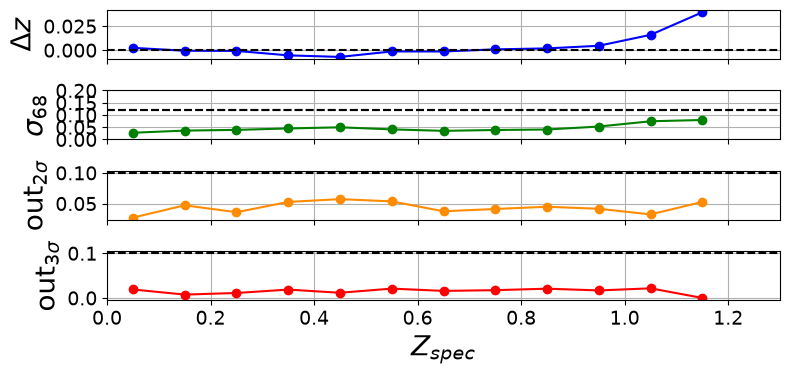

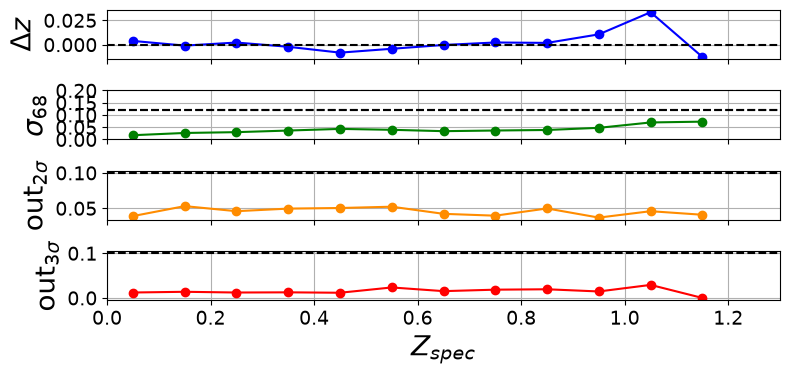

In [80]:
plot_metrics(y_test, y_pred_rf, 1.6, initial=0)
plot_metrics(y_test_clrmag_werr, y_pred_clrmag_werr, 1.6, initial=0)

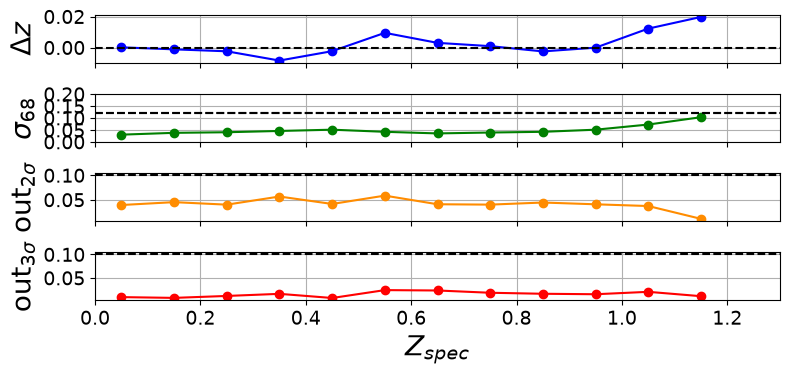

In [81]:
plot_metrics(redshifts, y_pred_cross_val, 1.6, initial=0)

#### Métricas por faixa de redshift, todos os conjuntos de atributos de uma vez

`plot_metrics` acima desenha quatro painéis para **um** modelo de cada vez. Abaixo,
`binned_metrics` separa o cálculo do desenho, e `plot_binned_metrics` sobrepõe todos
os conjuntos de atributos de `results` nos mesmos quatro painéis — assim a pergunta
"qual conjunto é melhor em $z = 0.8$?" vira uma comparação vertical dentro de um
único painel.

Três correções em relação ao cálculo original:

- $\sigma_{68}$ agora é um quantil de verdade (`np.quantile`), não `vetor_ordenado[int(0.68 \cdot N)]`;
- todas as métricas usam o resíduo normalizado $\Delta z/(1+z)$ — o código original
  misturava resíduo normalizado e não-normalizado entre as métricas;
- os intervalos dos bins são semiabertos, então galáxias exatamente na borda não são
  mais contadas em dois bins vizinhos.


In [82]:
# Colour + marker per feature set. The hue order is a validated colourblind-safe
# sequence; the marker shapes are a deliberate second encoding, so the series can
# still be told apart in greyscale, on a projector, or by a colourblind reader.
SERIES_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
SERIES_MARKERS = ['o', 's', '^', 'D', 'v']


def binned_metrics(z_spec, z_phot, bins, bin_by='phot', min_count=25):
    """Quality metrics of a photo-z estimate, computed in bins of redshift.

    Separated from the plotting on purpose: the numbers are useful on their own,
    and mixing the two is what made the original plot_metrics hard to fix.

    All metrics are built on the normalised residual dz = (z_phot - z_spec)/(1 + z_spec),
    which is the quantity the photo-z literature quotes. The original code mixed
    normalised and un-normalised residuals between metrics.

    Args:
        z_spec, z_phot: spectroscopic and photometric redshifts (same length).
        bins: bin edges, e.g. np.arange(0, 1.4, 0.1).

    Kwargs:
        bin_by: 'phot' bins on z_phot (what you can reproduce on an unlabelled
            sample), 'spec' bins on z_spec (the diagnostic view).
        min_count: bins holding fewer galaxies than this are dropped rather than
            plotted, so a bin with 3 objects does not get the same visual weight
            as one with 3000.

    Returns:
        dict of equal-length arrays: z (bin centre), n, bias, err_bias, sigma,
        sigma68, out2, out3.
    """
    z_spec = np.asarray(z_spec, dtype=float)
    z_phot = np.asarray(z_phot, dtype=float)

    dz = (z_phot - z_spec)/(1 + z_spec)
    binning_variable = z_phot if bin_by == 'phot' else z_spec

    columns = ('z', 'n', 'bias', 'err_bias', 'sigma', 'sigma68', 'out2', 'out3')
    out = {key: [] for key in columns}

    for low, high in zip(bins[:-1], bins[1:]):
        # Half-open interval: the original used <= on both edges, so galaxies
        # sitting exactly on an edge were counted in two neighbouring bins.
        in_bin = (binning_variable >= low) & (binning_variable < high)
        n = int(in_bin.sum())
        if n < min_count:
            continue

        d = dz[in_bin]
        bias = np.mean(d)
        sigma = np.std(d, ddof=1)

        out['z'].append(0.5 * (low + high))
        out['n'].append(n)
        out['bias'].append(bias)
        out['err_bias'].append(sigma/np.sqrt(n))
        out['sigma'].append(sigma)
        # A real quantile, not sorted_array[int(0.68 * len)].
        out['sigma68'].append(np.quantile(np.abs(d), 0.68))
        out['out2'].append(np.mean(np.abs(d - bias) > 2 * sigma))
        out['out3'].append(np.mean(np.abs(d - bias) > 3 * sigma))

    return {key: np.asarray(value) for key, value in out.items()}


def plot_binned_metrics(results, bins=None, bin_by='phot', min_count=25,
                        colors=None, markers=None, figsize=(11, 7)):
    """One 2x2 figure comparing every entry of `results` on four binned metrics.

    Each panel holds one metric and overlays all feature sets, so 'which feature
    set is best at z = 0.8' is a vertical comparison inside a single panel.

    Args:
        results: dict of {label: {'y_true': ..., 'y_pred': ...}}, as built by the
            training loop.

    Kwargs:
        bins: bin edges; defaults to np.arange(0, 1.4, 0.1).
        bin_by, min_count: passed through to binned_metrics.
        colors, markers: per-series styling, cycled if shorter than results.
        figsize: figure size in inches.

    Returns:
        (fig, axes)
    """
    if bins is None:
        bins = np.arange(0, 1.4, 0.1)
    colors = colors if colors is not None else SERIES_COLORS
    markers = markers if markers is not None else SERIES_MARKERS

    # (key in the stats dict, y label, reference value to mark)
    panels = [('bias',    r'$\langle \Delta z/(1+z) \rangle$', 0.0),
              ('sigma68', r'$\sigma_{68}$',                    0.12),
              ('out2',    r'out$_{2\sigma}$',                  0.10),
              ('out3',    r'out$_{3\sigma}$',                  0.10)]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True,
                             constrained_layout=True)

    for i, (name, result) in enumerate(results.items()):
        stats = binned_metrics(result['y_true'], result['y_pred'],
                               bins, bin_by=bin_by, min_count=min_count)
        style = dict(color=colors[i % len(colors)],
                     marker=markers[i % len(markers)],
                     markersize=5.5, markeredgecolor='white', markeredgewidth=0.6,
                     linewidth=1.8, label=name)

        for ax, (key, _, _) in zip(axes.flat, panels):
            if key == 'bias':
                # Only the bias panel gets error bars: it is the one place where
                # "is this consistent with zero?" is the actual question.
                ax.errorbar(stats['z'], stats['bias'], yerr=stats['err_bias'],
                            elinewidth=1, capsize=0, **style)
            else:
                ax.plot(stats['z'], stats[key], **style)

    for ax, (_, ylabel, reference) in zip(axes.flat, panels):
        ax.axhline(reference, color='0.55', linestyle='--', linewidth=1, zorder=1)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.grid(alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)  # recessive axes
        ax.tick_params(labelsize=10)

    xlabel = r'$z_\mathrm{phot}$' if bin_by == 'phot' else r'$z_\mathrm{spec}$'
    for ax in axes[-1]:
        ax.set_xlabel(xlabel, fontsize=13)
    axes.flat[0].set_xlim(bins[0], bins[-1])

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside lower center', ncols=len(labels),
               frameon=False, fontsize=10)
    fig.suptitle('Photo-z quality vs redshift, by feature set (bins with < %d '
                 'galaxies dropped)' % min_count, fontsize=13)

    return fig, axes


,MAE,sigma_NMAD,eta [%],bias
Magnitudes,0.0567,0.0384,2.3231,0.0024
Colors,0.0661,0.0402,4.7432,0.0039
Colors + mag_i,0.0530,0.0339,2.0145,0.0027
Magnitudes + errors,0.0615,0.0427,2.4862,0.0032
Colors + mag_i + errors,0.0519,0.0330,1.9969,0.0026


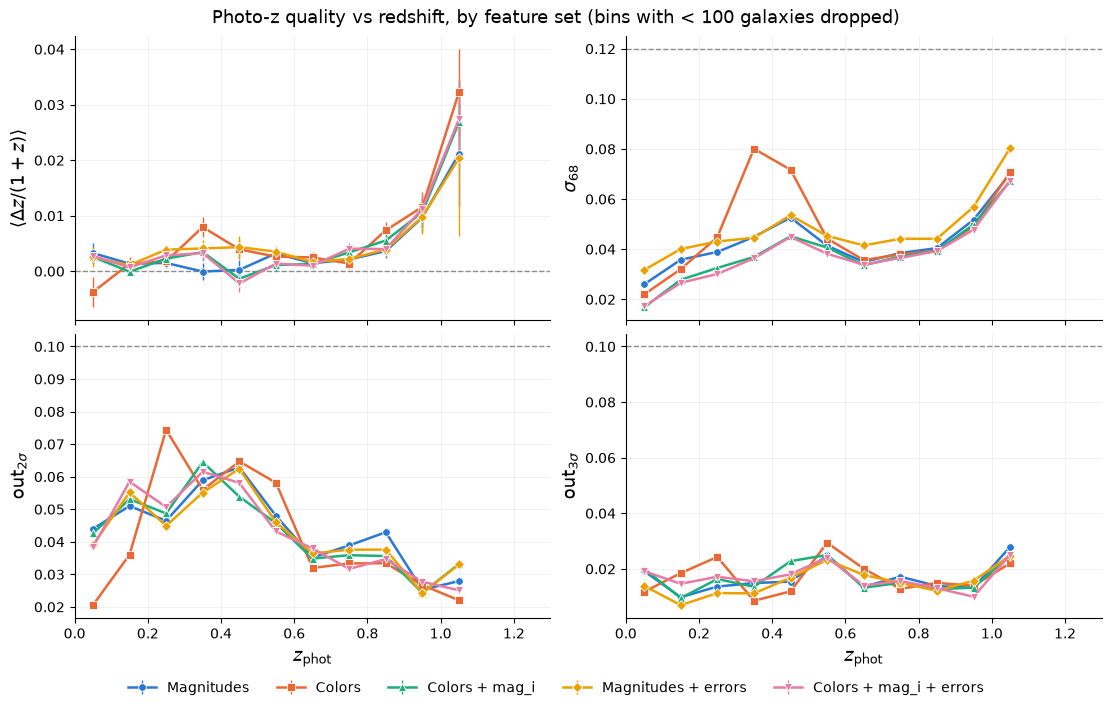

In [84]:
fig, axes = plot_binned_metrics(results, bin_by='phot', min_count=100)

# Table view of the same comparison. The legend maps colour+marker to feature set,
# but three of the five hues sit below 3:1 contrast on white, so the numbers must
# also be readable without relying on colour at all.
summary = pd.DataFrame(
    {name: {'MAE':        r['metrics']['mae'],
            'sigma_NMAD': r['metrics']['nmad'],
            'eta [%]':    100 * r['metrics']['eta'],
            'bias':       r['metrics']['bias']}
     for name, r in results.items()}).T
summary.round(4)


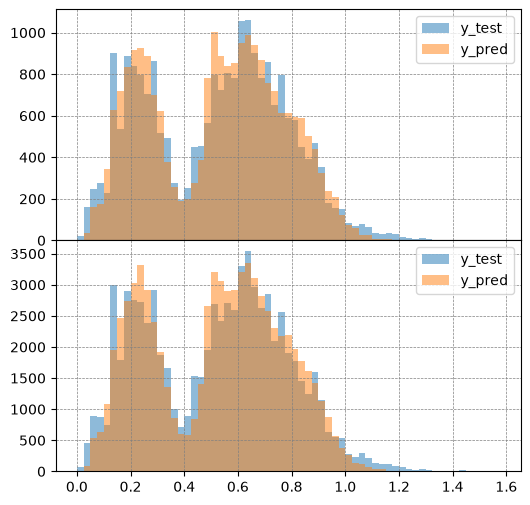

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=False)
plt.subplots_adjust(hspace=0.)

ax = axes[0]
#ax.set_xlabel('z', fontsize = 17)
ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5) 
_ = ax.hist(y_test, bins=np.arange(0, 1.6, 0.025), density=False, color='C0', alpha=0.5)
_ = ax.hist(y_pred_rf, bins=np.arange(0, 1.6, 0.025), density=False, color='C1', alpha=0.5)
#ax.set_ylim(0, 160)
ax.legend(['y_test', 'y_pred'])

ax = axes[1]

#ax.set_xlabel('z', fontsize = 17)
ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5) 
_ = ax.hist(redshifts, bins=np.arange(0, 1.6, 0.025), density=False, color='C0', alpha=0.5)
_ = ax.hist(y_pred_cross_val, bins=np.arange(0, 1.6, 0.025), density=False, color='C1', alpha=0.5)
#ax.set_ylim(0, 160)
ax.legend(['y_test', 'y_pred'])

#### Distribuição de redshifts $N(z)$: verdade vs. reconstrução

A célula acima sobrepõe dois histogramas preenchidos com `alpha=0.5`. Onde eles se
cruzam surge uma terceira cor, que não corresponde a nenhuma das duas entradas da
legenda — e é justamente na região de sobreposição que está a informação. (A legenda
do segundo painel também está trocada: ele desenha `redshifts` e `y_pred_cross_val`,
mas rotula `y_test` e `y_pred`.)

Abaixo, o $N(z)$ espectroscópico é desenhado **uma única vez**, como referência
cinza preenchida — é a mesma amostra de teste para todos os conjuntos de atributos.
Cada predição vira um contorno em degraus por cima, e o painel inferior mostra a
razão predito/verdadeiro, que é onde o desvio fica realmente visível.


In [85]:
# Line style as a second encoding, for the same reason the panels above carry
# marker shapes: three of the five hues are low contrast on white.
SERIES_LINESTYLES = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]


def plot_nz(results, bins=None, colors=None, linestyles=None,
            ratio=True, figsize=(10, 7.5)):
    """Compare the true and the recovered redshift distribution N(z).

    The spectroscopic N(z) is drawn once, as a filled grey reference, because it
    is the same test sample for every feature set - five identical curves on top
    of each other would just be ink. Each prediction is a step outline over it.

    Two filled semi-transparent histograms (as in the cell above) are avoided on
    purpose: where they overlap, the eye sees a third colour that belongs to
    neither series and cannot be matched to the legend.

    Args:
        results: dict of {label: {'y_true': ..., 'y_pred': ...}}, as built by the
            training loop. Entries whose true N(z) differs from the first one
            (cross-validation over the full catalogue, say) get their own faint
            reference curve instead of being compared against the wrong sample.

    Kwargs:
        bins: bin edges; defaults to np.arange(0, 1.45, 0.05). Finer bins make
            the ratio panel noisier, not more informative.
        colors, linestyles: per-series styling, cycled if shorter than results.
        ratio: add the predicted/true panel underneath.
        figsize: figure size in inches.

    Returns:
        (fig, axes)
    """
    if bins is None:
        bins = np.arange(0, 1.45, 0.05)
    colors = colors if colors is not None else SERIES_COLORS
    linestyles = linestyles if linestyles is not None else SERIES_LINESTYLES

    centres = 0.5 * (bins[:-1] + bins[1:])

    if ratio:
        fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]},
                                 constrained_layout=True)
        ax_main, ax_ratio = axes
    else:
        fig, ax_main = plt.subplots(figsize=figsize, constrained_layout=True)
        axes, ax_ratio = np.array([ax_main]), None

    reference = None
    for i, (name, result) in enumerate(results.items()):
        y_true = np.asarray(result['y_true'], dtype=float)
        y_pred = np.asarray(result['y_pred'], dtype=float)
        n_true, _ = np.histogram(y_true, bins=bins)
        n_pred, _ = np.histogram(y_pred, bins=bins)

        colour = colors[i % len(colors)]
        style = linestyles[i % len(linestyles)]

        if reference is None:
            reference = n_true
            ax_main.stairs(n_true, bins, fill=True, color='0.87', zorder=1,
                           label='Spectroscopic (truth)')
            ax_main.stairs(n_true, bins, color='0.45', linewidth=1.2, zorder=2)
        elif not np.array_equal(n_true, reference):
            ax_main.stairs(n_true, bins, color=colour, linewidth=1,
                           alpha=0.45, zorder=2)

        ax_main.stairs(n_pred, bins, color=colour, linestyle=style,
                       linewidth=1.8, zorder=3, label=name)

        if ax_ratio is not None:
            # Bins with no true galaxies have no meaningful ratio - leave a gap
            # rather than drawing a spike or a zero.
            with np.errstate(divide='ignore', invalid='ignore'):
                r = np.where(n_true > 0, n_pred/np.where(n_true > 0, n_true, 1), np.nan)
            ax_ratio.plot(centres, r, color=colour, linestyle=style, linewidth=1.6)

    ax_main.set_ylabel('Galaxies per bin', fontsize=12)
    ax_main.set_xlim(bins[0], bins[-1])

    for ax in axes:
        ax.grid(alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=10)

    if ax_ratio is not None:
        ax_ratio.axhline(1.0, color='0.55', linestyle='--', linewidth=1, zorder=1)
        ax_ratio.set_ylabel('pred / true', fontsize=11)
        ax_ratio.set_xlabel(r'$z$', fontsize=13)
    else:
        ax_main.set_xlabel(r'$z$', fontsize=13)

    handles, labels = ax_main.get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside lower center',
               ncols=3, frameon=False, fontsize=10)
    fig.suptitle('Recovered vs true redshift distribution', fontsize=13)

    return fig, axes


,<z> true,<z> pred,shift
Magnitudes,0.5212,0.5203,-0.0009
Colors,0.5212,0.5204,-0.0008
Colors + mag_i,0.5212,0.5212,-0.0000
Magnitudes + errors,0.5212,0.5208,-0.0005
Colors + mag_i + errors,0.5212,0.5211,-0.0001


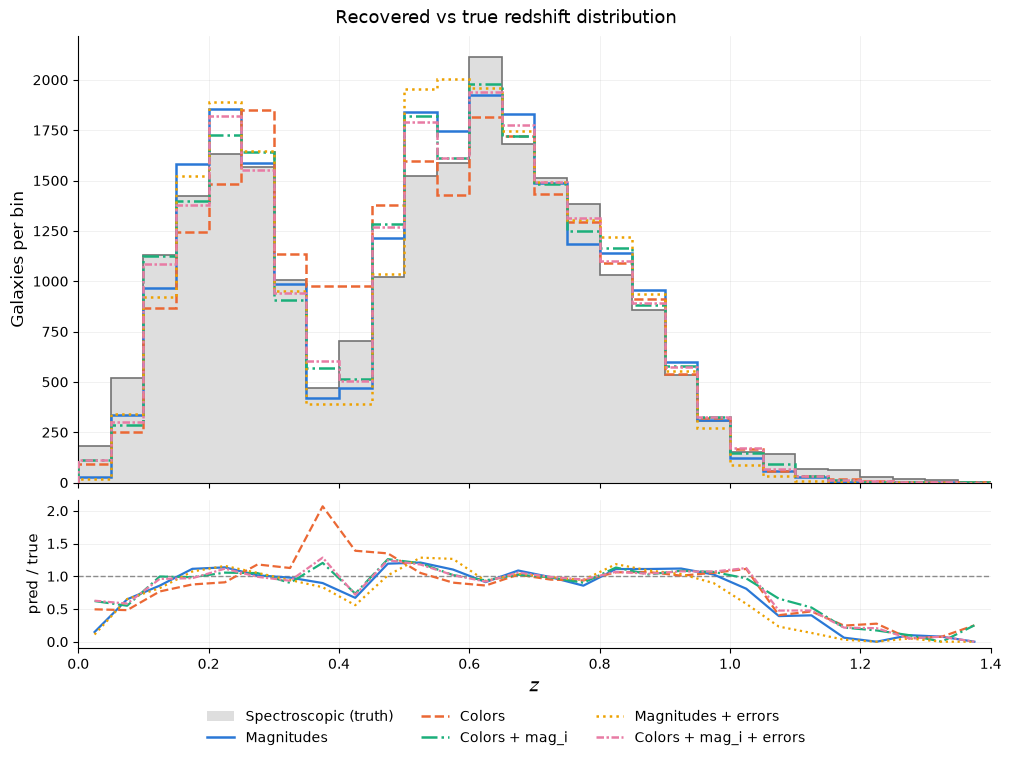

In [86]:
fig, axes = plot_nz(results)

# The number that actually matters downstream: how far the mean of the recovered
# N(z) sits from the mean of the true one.
nz_summary = pd.DataFrame(
    {name: {'<z> true':  np.mean(np.asarray(r['y_true'], dtype=float)),
            '<z> pred':  np.mean(np.asarray(r['y_pred'], dtype=float)),
            'shift':     np.mean(np.asarray(r['y_pred'], dtype=float))
                         - np.mean(np.asarray(r['y_true'], dtype=float))}
     for name, r in results.items()}).T
nz_summary.round(4)


# SOBRAS

## 2. Treino/teste de três algoritmos de aprendizado de máquina

### 2.1. Rede neural (Multi-layer perceptron)

In [18]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

mlp_test_mae = mean_absolute_error(y_test, y_pred_mlp)
print("Multi-Layer Perceptron Validation MAE:", mlp_test_mae)

Multi-Layer Perceptron Validation MAE: 0.0759030763635313


### 2.2. Árvore de decisão

In [19]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_test_mae = mean_absolute_error(y_test, y_pred_dt)
print("Decision Tree Validation MAE:", dt_test_mae)

Decision Tree Validation MAE: 0.07878402305884946


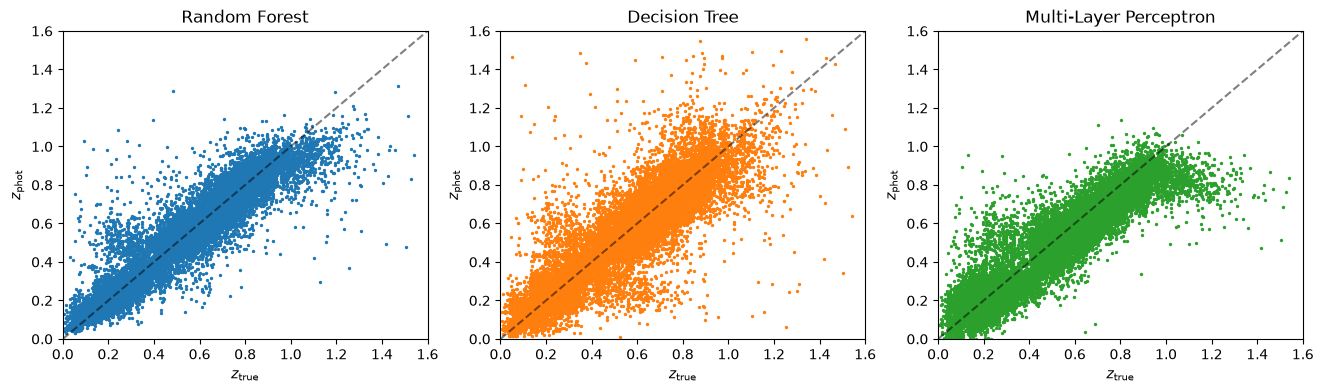

In [20]:
# Compare plots from three results

titles = ["Multi-Layer perceptron", "Decision tree", "Random forest"]
data_sets = [y_pred_mlp, y_pred_dt, y_pred_rf]
colors = ["C0", "C1", "C2"]

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.title("Random Forest")
plt.scatter(y_test, y_pred_rf, s=2, color="C0")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
plt.xlabel(r"$z_\mathrm{true}$")
plt.ylabel(r"$z_\mathrm{phot}$")

plt.subplot(1, 3, 2)
plt.title("Decision Tree")
plt.scatter(y_test, y_pred_dt, s=2, color="C1")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
plt.xlabel(r"$z_\mathrm{true}$")
plt.ylabel(r"$z_\mathrm{phot}$")

plt.subplot(1, 3, 3)
plt.title("Multi-Layer Perceptron")
plt.scatter(y_test, y_pred_mlp, s=2, color="C2")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
_ = plt.xlabel(r"$z_\mathrm{true}$")
_ = plt.ylabel(r"$z_\mathrm{phot}$")